## 1. Custom CNN Galaxy Morphology Classification

This section provides the initial setup for the Galaxy Zoo 2 classification project. It includes the required library imports, reproducibility settings, GPU and mixed-precision configuration, and the definition of the project’s data, image, and results directories.


In [ ]:
!pip -q install --upgrade gdown

import os
import random
import time
import zipfile
import json
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

GPUS = tf.config.list_physical_devices('GPU')
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if GPUS:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    ROOT = Path('/kaggle/working/GalaxyZoo_CustomCNN_Clean')
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/GalaxyZoo_CustomCNN_Clean')
    except (ImportError, NotImplementedError):
        ROOT = Path('/kaggle/working/GalaxyZoo_CustomCNN_Clean')

DATA_DIR = ROOT / 'data'
IMAGE_ROOT = ROOT / 'images_gz2'
IMAGE_FOLDER = IMAGE_ROOT / 'images'
RESULTS_DIR = ROOT / 'results_7782'

for folder in (DATA_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print('=' * 72)
print('GALAXY ZOO 2 — CustomCNN IMPROVED PIPELINE')
print('=' * 72)
print('TensorFlow:', tf.__version__)
print('GPU(s):', GPUS if GPUS else 'No GPU detected')
print('Precision policy:', tf.keras.mixed_precision.global_policy())
print('Workspace:', ROOT)


GALAXY ZOO 2 — CustomCNN IMPROVED PIPELINE
TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: <DTypePolicy "mixed_float16">
Workspace: /kaggle/working/GalaxyZoo_CustomCNN_Clean


## 2. Dataset and Image Preparation

This section prepares the main Galaxy Zoo 2 dataset files required for the classification pipeline. It covers the galaxy filename mapping, Hart16 catalog, and image archive, while avoiding unnecessary re-downloads or repeated extraction when the required files are already available.


In [36]:
MAPPING_PATH = DATA_DIR / 'gz2_filename_mapping.csv'
HART_PATH = DATA_DIR / 'gz2_hart16.csv.gz'
ZIP_PATH = DATA_DIR / 'images_gz2.zip'

downloads = {
    MAPPING_PATH: '1KPJdI9yEIOOEk-sfSkCM7zqSgjBPPTZW',
    HART_PATH: '1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc',
    ZIP_PATH: '1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8',
}

for path, file_id in downloads.items():
    if not path.exists():
        print(f'Downloading {path.name} ...')
        gdown.download(id=file_id, output=str(path), quiet=False)
    else:
        print(f'Found: {path.name}')

if not IMAGE_FOLDER.exists():
    print('Extracting image archive ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as archive:
        archive.extractall(IMAGE_ROOT)
else:
    print('Image folder already exists; full re-extraction skipped.')

Downloading...
From: https://drive.google.com/uc?id=1KPJdI9yEIOOEk-sfSkCM7zqSgjBPPTZW
To: /kaggle/working/GalaxyZoo_CustomCNN_Clean/data/gz2_filename_mapping.csv
100%|██████████| 13.2M/13.2M [00:00<00:00, 58.3MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc
From (redirected): https://drive.google.com/uc?id=1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc&confirm=t&uuid=b2c19fac-ad46-453e-8c4e-15601f9eb48d
To: /kaggle/working/GalaxyZoo_CustomCNN_Clean/data/gz2_hart16.csv.gz
100%|██████████| 78.5M/78.5M [00:01<00:00, 72.5MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8
From (redirected): https://drive.google.com/uc?id=1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8&confirm=t&uuid=993efe66-5ea1-40b7-8977-b146ff3c39a7
To: /kaggle/working/GalaxyZoo_CustomCNN_Clean/data/images_gz2.zip
100%|██████████| 3.35G/3.35G [00:29<00:00, 115MB/s] 


Extracting image archive ...


## 3. Loading and Merging the Metadata

The mapping and Hart16 tables are loaded with pandas and their shapes, sample rows, and columns are checked. `objid` and `dr7objid` are converted to numeric values, then both tables are merged so each galaxy can be connected to its image `asset_id` and Galaxy Zoo information.


In [37]:
mapping = pd.read_csv(MAPPING_PATH)
hart = pd.read_csv(HART_PATH)

print("Mapping shape:", mapping.shape)
print("Hart shape:", hart.shape)

display(mapping.head())
display(hart.head())

print("Mapping columns:")
print(mapping.columns.tolist())

print("\nHart columns:")
print(hart.columns.tolist())

mapping["objid"] = pd.to_numeric(mapping["objid"], errors="coerce").astype("Int64")
hart["dr7objid"] = pd.to_numeric(hart["dr7objid"], errors="coerce").astype("Int64")

merged = mapping.merge(
    hart,
    left_on="objid",
    right_on="dr7objid",
    how="inner",
    validate="many_to_one",
)

df = merged.copy()
df["asset_id"] = pd.to_numeric(df["asset_id"], errors="coerce")
df = df.dropna(subset=["asset_id"]).copy()
df["asset_id"] = df["asset_id"].astype("int64")

print("Merged shape:", df.shape)
display(df[["objid", "asset_id", "gz2_class"]].head(10))


Mapping shape: (355990, 3)
Hart shape: (239695, 231)


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


Mapping columns:
['objid', 'sample', 'asset_id']

Hart columns:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_we

,objid,asset_id,gz2_class
0,587722981741363294,3,Sb
1,587722981741363323,4,Sc?l
2,587722981741559888,5,Er
3,587722981741625481,6,Sc1t
4,587722981741625484,7,Sb
5,587722981741625520,8,Ei
6,587722981741625545,9,Er
7,587722981741756545,11,Sb
8,587722981741756579,12,SBc
9,587722981741822057,13,Ec


## 4. Creating the Three Galaxy Classes

A vote-fraction threshold of 0.80 is used to identify high-confidence elliptical, spiral, and irregular galaxies from the Galaxy Zoo classifications. Samples satisfying multiple class criteria are excluded to ensure that each selected galaxy has a single class label.


In [ ]:
THRESHOLD = 0.80

required_columns = [
    "t01_smooth_or_features_a01_smooth_weighted_fraction",
    "t01_smooth_or_features_a02_features_or_disk_weighted_fraction",
    "t04_spiral_a08_spiral_weighted_fraction",
    "t08_odd_feature_a22_irregular_weighted_fraction",
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise KeyError(f"Missing columns in the Hart CSV: {missing_columns}")

elliptical_mask = (
    df["t01_smooth_or_features_a01_smooth_weighted_fraction"] >= THRESHOLD
)

spiral_mask = (
    (df["t01_smooth_or_features_a02_features_or_disk_weighted_fraction"] >= THRESHOLD)
    & (df["t04_spiral_a08_spiral_weighted_fraction"] >= THRESHOLD)
)

irregular_mask = (
    df["t08_odd_feature_a22_irregular_weighted_fraction"] >= THRESHOLD
)

candidate_count = (
    elliptical_mask.astype("int8")
    + spiral_mask.astype("int8")
    + irregular_mask.astype("int8")
)

df["label"] = pd.NA
df.loc[elliptical_mask & (candidate_count == 1), "label"] = "elliptical"
df.loc[spiral_mask & (candidate_count == 1), "label"] = "spiral"
df.loc[irregular_mask & (candidate_count == 1), "label"] = "irregular"

print("Overlapping high-confidence rows removed:", int((candidate_count > 1).sum()))

df = df.dropna(subset=["label"]).copy()
print(df["label"].value_counts())


Overlapping high-confidence rows removed: 4486
label
elliptical    103196
spiral         22780
irregular       3296
Name: count, dtype: int64


## 5. Balancing the Dataset

Only rows with an image actually present in the image folder are kept. The smallest class size is used as `N_PER_CLASS`, and the same number of samples is randomly selected from each class. This keeps elliptical, spiral, and irregular equally represented.


In [39]:
available_image_ids = {p.stem for p in IMAGE_FOLDER.glob("*.jpg")}

df_with_images = df[
    df["asset_id"].astype(str).isin(available_image_ids)
].copy()

available_counts = df_with_images["label"].value_counts()

missing_classes = {"elliptical", "spiral", "irregular"} - set(available_counts.index)

if missing_classes:
    raise ValueError(
        f"No samples with images found for the following classes: {missing_classes}"
    )

N_PER_CLASS = int(available_counts.min())

if N_PER_CLASS < 1000:
    print(
        "WARNING: The smallest class has fewer than 1000 samples; "
        "reaching the 80% target may be more difficult."
    )

balanced_df = pd.concat(
    [
        group.sample(n=N_PER_CLASS, random_state=SEED)
        for _, group in df_with_images.groupby("label", sort=True)
    ],
    ignore_index=True,
)

balanced_df = balanced_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Available before balancing:")
print(available_counts)
print()

print("Balanced:")
print(balanced_df["label"].value_counts())
print()

print("Total images:", len(balanced_df))

Available before balancing:
label
elliptical    103173
spiral         22779
irregular       3295
Name: count, dtype: int64

Balanced:
label
irregular     3295
elliptical    3295
spiral        3295
Name: count, dtype: int64

Total images: 9885


## 6. Organizing Images by Class

The balanced images are copied into separate `elliptical`, `spiral`, and `irregular` folders. The code also counts copied and missing images and stops if an unexpected image is missing.


In [40]:
import shutil

THREE_CLASS_DIR = Path("/kaggle/working/three_class_data")

assert IMAGE_FOLDER.is_dir()
print("Images will be read directly from Kaggle Input:", IMAGE_FOLDER)

classes = ["elliptical", "spiral", "irregular"]

if THREE_CLASS_DIR.exists():
    shutil.rmtree(THREE_CLASS_DIR)

for cls in classes:
    (THREE_CLASS_DIR / cls).mkdir(parents=True, exist_ok=True)

copied = 0
missing = 0

for row in balanced_df.itertuples(index=False):
    asset_id = int(row.asset_id)
    label = row.label
    src = IMAGE_FOLDER / f"{asset_id}.jpg"
    dst = THREE_CLASS_DIR / label / f"{asset_id}.jpg"

    if src.is_file():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing += 1

print("Copied:", copied)
print("Missing:", missing)

if missing:
    raise RuntimeError(
        "Unexpected missing images were detected after balancing."
    )

Images will be read directly from Kaggle Input: /kaggle/working/GalaxyZoo_CustomCNN_Clean/images_gz2/images
Copied: 9885
Missing: 0


## 7. Train, Validation, and Test Split

The balanced dataset is split into **68% training, 12% validation, and 20% test data** for each class. The next cell prints the number of images in every split and class to make sure the split was created correctly.


In [41]:
SPLIT_DIR = Path("/kaggle/working/dataset_split")

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "validation", "test"]:
    for cls in classes:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in classes:
    files = sorted((THREE_CLASS_DIR / cls).glob("*.jpg"))
    rng = random.Random(SEED)
    rng.shuffle(files)

    n_total = len(files)
    n_test = int(round(n_total * 0.20))
    n_validation = int(round(n_total * 0.12))

    test_files = files[:n_test]
    validation_files = files[n_test:n_test + n_validation]
    train_files = files[n_test + n_validation:]

    for split, split_files in [
        ("train", train_files),
        ("validation", validation_files),
        ("test", test_files),
    ]:
        for src in split_files:
            shutil.copy2(src, SPLIT_DIR / split / cls / src.name)

print("Fresh 68% train / 12% validation / 20% test split created.")

Fresh 68% train / 12% validation / 20% test split created.


In [42]:
for split in ["train", "validation", "test"]:
    print()
    print(split.upper())
    total = 0
    for cls in classes:
        count = sum(1 for _ in (SPLIT_DIR / split / cls).glob("*.jpg"))
        total += count
        print(f"{cls}: {count}")
    print("Total:", total)



TRAIN
elliptical: 2241
spiral: 2241
irregular: 2241
Total: 6723

VALIDATION
elliptical: 395
spiral: 395
irregular: 395
Total: 1185

TEST
elliptical: 659
spiral: 659
irregular: 659
Total: 1977


## 8. TensorFlow Datasets and Data Check

The three folders are loaded as TensorFlow datasets with an image size of **150 × 150** and batch size **32**. Training data is shuffled, while validation and test data keep a fixed order. A sample batch is then checked and nine training images are displayed with their labels.


In [44]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_file_paths = list(test_dataset.file_paths)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 6723 files belonging to 3 classes.
Found 1185 files belonging to 3 classes.
Found 1977 files belonging to 3 classes.


Batch image shape: (32, 150, 150, 3)
Batch label shape: (32,)
Pixel range: 0.0 -> 255.0


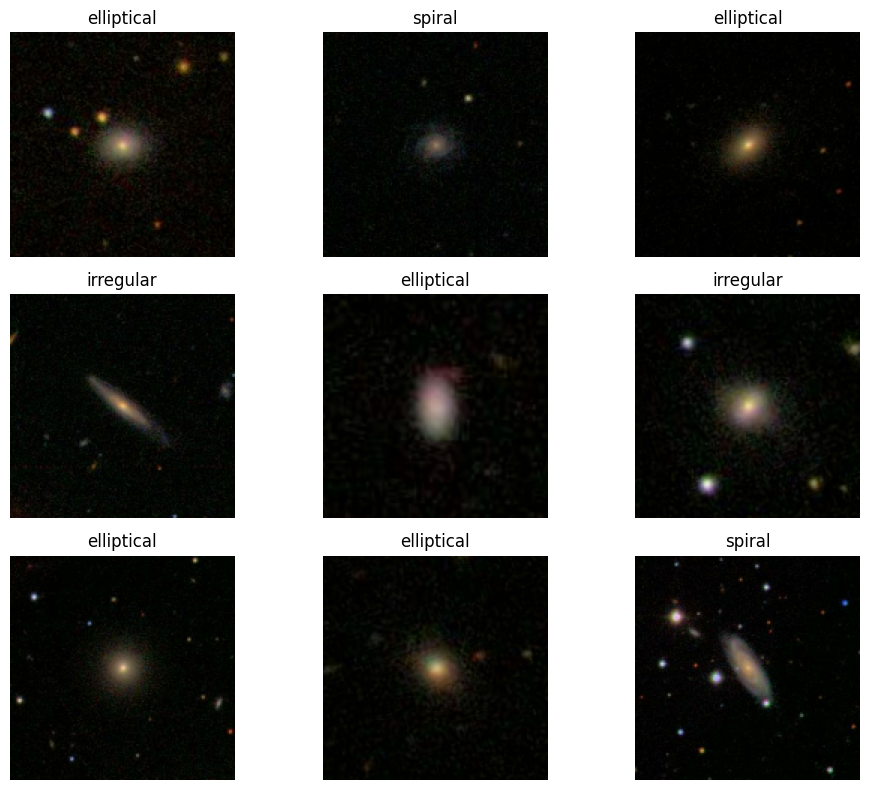

In [46]:
images, labels_batch = next(iter(train_dataset))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels_batch.shape)
print("Pixel range:", float(tf.reduce_min(images)), "->", float(tf.reduce_max(images)))

plt.figure(figsize=(10, 8))
for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.cast(images[i], tf.uint8).numpy())
    plt.title(classes[int(labels_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Data Augmentation and Residual Blocks

This cell defines the augmentation used during training: flips, rotation, zoom, translation, and contrast changes. It also defines reusable convolution and residual-block functions that are used to build the custom CNN.


In [47]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.50, fill_mode="reflect"),
    layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="reflect",
    ),
    layers.RandomTranslation(
        height_factor=0.04,
        width_factor=0.04,
        fill_mode="reflect",
    ),
    layers.RandomContrast(0.10),
], name="galaxy_augmentation")

def conv_bn_act(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=None if name is None else f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(
        name=None if name is None else f"{name}_bn"
    )(x)
    x = layers.Activation(
        "swish",
        name=None if name is None else f"{name}_act"
    )(x)
    return x


def residual_block(x, filters, downsample=False, spatial_dropout=0.0, name="block"):
    stride = 2 if downsample else 1
    shortcut = x

    x = conv_bn_act(
        x,
        filters,
        kernel_size=3,
        strides=stride,
        name=f"{name}_1",
    )

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_2_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_2_bn")(x)

    if downsample or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"{name}_shortcut_conv",
        )(shortcut)
        shortcut = layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.Activation("swish", name=f"{name}_out")(x)

    if spatial_dropout > 0:
        x = layers.SpatialDropout2D(
            spatial_dropout,
            name=f"{name}_spatial_dropout",
        )(x)

    return x


## 10. Custom CNN Architecture

The network starts with augmentation and pixel rescaling, then passes the images through residual stages with **32, 64, 128, and 256 filters**. Spatial dropout increases in the deeper stages. Global average pooling and dense layers are used before the final three-class softmax output.


In [48]:
inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")

x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255.0, name="rescale")(x)

x = conv_bn_act(x, 32, kernel_size=5, strides=2, name="stem")

x = residual_block(x, 32,  downsample=False, spatial_dropout=0.00, name="stage1_block1")

x = residual_block(x, 64,  downsample=True,  spatial_dropout=0.05, name="stage2_block1")
x = residual_block(x, 64,  downsample=False, spatial_dropout=0.05, name="stage2_block2")

x = residual_block(x, 128, downsample=True,  spatial_dropout=0.10, name="stage3_block1")
x = residual_block(x, 128, downsample=False, spatial_dropout=0.10, name="stage3_block2")

x = residual_block(x, 256, downsample=True,  spatial_dropout=0.15, name="stage4_block1")
x = residual_block(x, 256, downsample=False, spatial_dropout=0.15, name="stage4_block2")

x = layers.GlobalAveragePooling2D(name="global_average_pool")(x)

x = layers.Dense(
    256,
    activation="swish",
    kernel_initializer="he_normal",
    name="classifier_dense",
)(x)
x = layers.BatchNormalization(name="classifier_bn")(x)
x = layers.Dropout(0.40, name="classifier_dropout")(x)

outputs = layers.Dense(
    len(classes),
    activation="softmax",
    dtype="float32",
    name="predictions",
)(x)

model_cnn = models.Model(inputs, outputs, name="CustomGalaxyResidualCNN")
model_cnn.summary()


Model: "CustomGalaxyResidualCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 150, 150,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ galaxy_augmentation │ (None, 150, 150,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescale (Rescaling) │ (None, 150, 150,  │          0 │ galaxy_augmentat… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 75, 75,    │      2,400 │ rescale[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 75, 75,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_act            │ (None, 75, 75,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_1_co… │ (None, 75, 75,    │      9,216 │ stem_act[0][0]    │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_1_bn  │ (None, 75, 75,    │        128 │ stage1_block1_1_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_1_act │ (None, 75, 75,    │          0 │ stage1_block1_1_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_2_co… │ (None, 75, 75,    │      9,216 │ stage1_block1_1_… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_2_bn  │ (None, 75, 75,    │        128 │ stage1_block1_2_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 75, 75,    │          0 │ stage1_block1_2_… │
│ (Add)               │ 32)               │            │ stem_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 75, 75,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_1_co… │ (None, 38, 38,    │     18,432 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_1_bn  │ (None, 38, 38,    │        256 │ stage2_block1_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_1_act │ (None, 38, 38,    │          0 │ stage2_block1_1_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_2_co… │ (None, 38, 38,    │     36,864 │ stage2_block1_1_

 Total params: 2,850,275 (10.87 MB)

 Trainable params: 2,845,091 (10.85 MB)

 Non-trainable params: 5,184 (20.25 KB)

## 11. Model Compilation and Training Callbacks

The model uses **AdamW** when available, with Adam as a fallback. It is compiled with sparse categorical cross-entropy and accuracy. The callbacks save the best model by validation accuracy, reduce the learning rate when validation loss stops improving, and use early stopping to avoid unnecessary training.


In [49]:
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)  
BEST_MODEL_PATH = RESULTS_DIR / "best_model.keras"

try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=7e-5,
        clipnorm=1.0,
    )
    print("Optimizer: AdamW")
except Exception:
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=3e-4,
        clipnorm=1.0,
    )
    print("Optimizer: Adam (fallback)")

model_cnn.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.35,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        min_delta=0.0005,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        str(RESULTS_DIR / "epoch_log.csv")
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

Optimizer: AdamW


## 12. Training the Model

The CNN is trained for up to **50 epochs** using the training and validation datasets. After training, the full history is saved to CSV, and the epoch with the highest validation accuracy is reported together with the saved best-model path.


In [51]:
history_cnn = model_cnn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1,
)

HISTORY_PATH = RESULTS_DIR / "training_history.csv"

history_df = pd.DataFrame(history_cnn.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

history_df.to_csv(HISTORY_PATH)

best_epoch = int(history_df["val_accuracy"].idxmax())
best_val_acc = float(history_df.loc[best_epoch, "val_accuracy"])

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_acc * 100:.2f}%")
print("Saved model:", BEST_MODEL_PATH)
print("Saved history:", HISTORY_PATH)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5552 - loss: 1.0757
Epoch 1: val_accuracy improved from None to 0.51224, saving model to results/best_model.keras

Epoch 1: finished saving model to results/best_model.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.5692 - loss: 1.0215 - val_accuracy: 0.5122 - val_loss: 1.8768 - learning_rate: 3.0000e-04
Epoch 2/50
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6130 - loss: 0.9307
Epoch 2: val_accuracy improved from 0.51224 to 0.69030, saving model to results/best_model.keras

Epoch 2: finished saving model to results/best_model.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.6378 - loss: 0.8901 - val_accuracy: 0.6903 - val_loss: 1.0827 - learning_rate: 3.0000e-04
Epoch 3/50
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6779 - loss: 0.7886
Epoch 3: val_accuracy did not improve from 0.69030
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.7009 - loss: 0.7450 - val

## 13. Final Test Evaluation

The checkpoint with the best validation accuracy is loaded and evaluated on the untouched test set. Predictions are collected for every test image, then accuracy, macro precision, macro recall, macro F1, weighted F1, and the full per-class classification report are calculated.


In [52]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

best_model_cnn = tf.keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_accuracy = best_model_cnn.evaluate(
    test_dataset,
    verbose=1,
)

print("\n" + "=" * 60)
print("CUSTOM CNN — FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8275 - loss: 0.4086

CUSTOM CNN — FINAL TEST RESULTS
Test Loss: 0.4086
Test Accuracy: 82.75%


In [53]:
y_true = []
prediction_probabilities = []

for images, labels in test_dataset:
    probs = best_model_cnn.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    prediction_probabilities.append(probs)

y_true = np.array(y_true)
prediction_probabilities = np.vstack(prediction_probabilities)

y_pred = np.argmax(
    prediction_probabilities,
    axis=1,
)

accuracy = accuracy_score(y_true, y_pred)

print("\n" + "=" * 60)
print("CUSTOM CNN — PREDICTION METRICS")
print("=" * 60)

print(f"Accuracy: {accuracy * 100:.2f}%")


CUSTOM CNN — PREDICTION METRICS
Accuracy: 82.75%


In [54]:
macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

print("\n--- Classification Report ---")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4,
        zero_division=0,
    )
)

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")


--- Classification Report ---
              precision    recall  f1-score   support

  elliptical     0.9194    0.7618    0.8332       659
      spiral     0.9250    0.8422    0.8817       659
   irregular     0.6968    0.8786    0.7772       659

    accuracy                         0.8275      1977
   macro avg     0.8471    0.8275    0.8307      1977
weighted avg     0.8471    0.8275    0.8307      1977

Macro Precision: 0.8471
Macro Recall:    0.8275
Macro F1:        0.8307
Weighted F1:     0.8307


## 14. Confusion Matrix

The confusion matrix compares the true and predicted labels for all three classes. The values are written inside the matrix and the figure is saved in the results folder at high resolution.


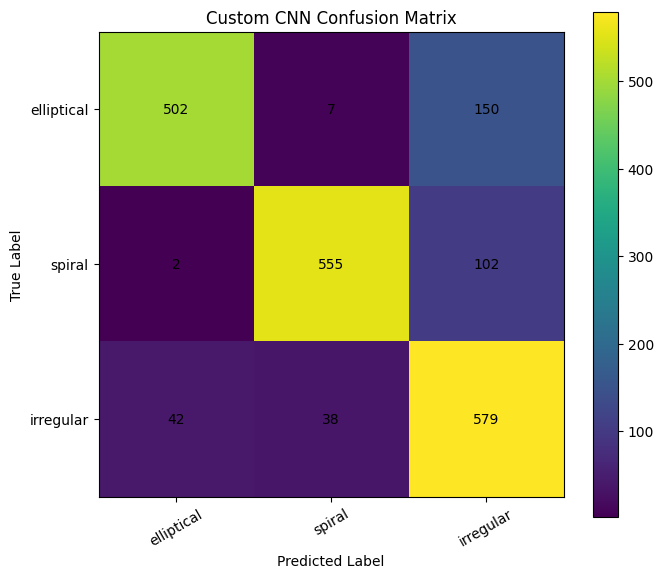

Saved: results/custom_cnn_confusion_matrix.png


In [55]:
cm = confusion_matrix(
    y_true,
    y_pred,
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=30,
)

plt.yticks(
    range(len(classes)),
    classes,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Custom CNN Confusion Matrix")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.tight_layout()

CONFUSION_PATH = RESULTS_DIR / "custom_cnn_confusion_matrix.png"

plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", CONFUSION_PATH)

## 15. Training History and Learning Curves

Training and validation accuracy and loss are plotted across the completed epochs. The same values are also saved to a CSV file. Finally, the epoch with the highest validation accuracy is calculated again from the recorded history.


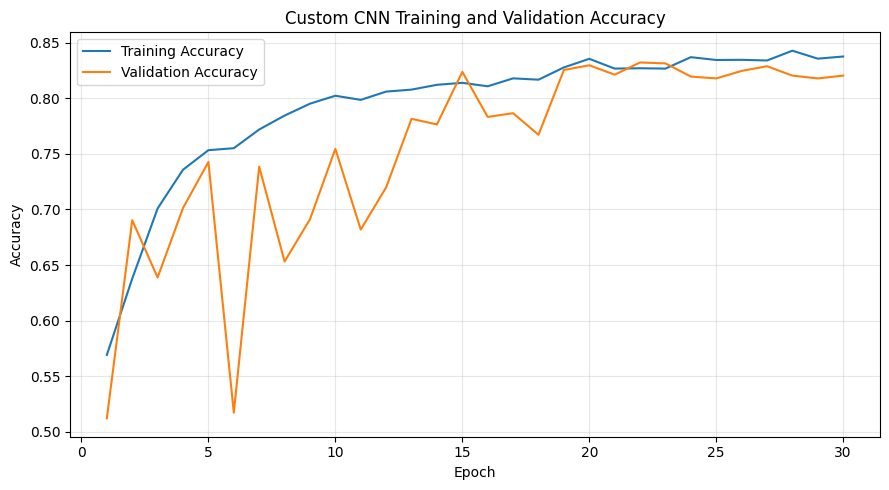

In [ ]:
train_accuracy = history_cnn.history["accuracy"]
val_accuracy = history_cnn.history["val_accuracy"]

train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy",
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Custom CNN Training and Validation Accuracy")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_GRAPH_PATH = RESULTS_DIR / "custom_cnn_accuracy_curve.png"

plt.savefig(
    ACCURACY_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

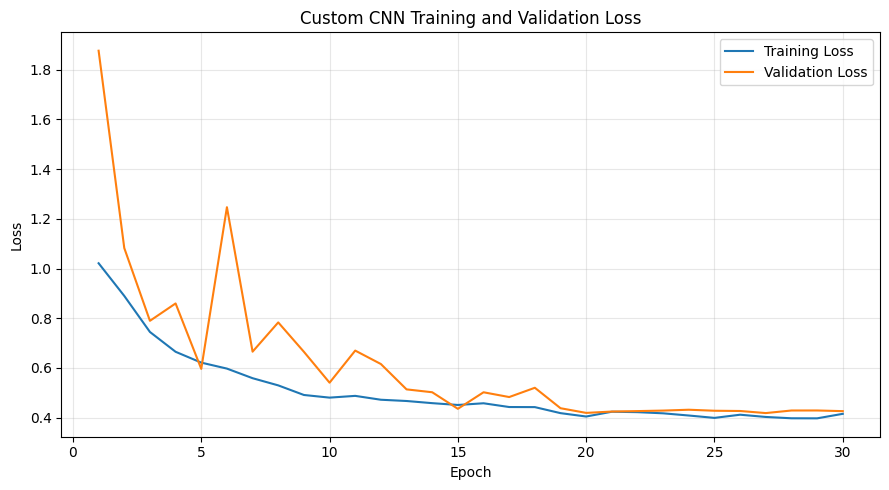

In [57]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_loss,
    label="Training Loss",
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Custom CNN Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_GRAPH_PATH = RESULTS_DIR / "custom_cnn_loss_curve.png"

plt.savefig(
    LOSS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [58]:
history_df = pd.DataFrame({
    "epoch": list(epochs),
    "train_accuracy": train_accuracy,
    "validation_accuracy": val_accuracy,
    "train_loss": train_loss,
    "validation_loss": val_loss,
})

HISTORY_PATH = RESULTS_DIR / "custom_cnn_training_history.csv"

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

print("Saved:", HISTORY_PATH)

Saved: results/custom_cnn_training_history.csv


In [59]:
best_epoch = int(
    np.argmax(val_accuracy) + 1
)

best_val_accuracy = float(
    np.max(val_accuracy)
)

print(f"Best epoch: {best_epoch}")
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

Best epoch: 22
Best validation accuracy: 83.21%


## 16. Saving and Inspecting Test Predictions

A CSV file is created for every test image with its filename, true class, predicted class, prediction confidence, and whether the prediction was correct. The incorrect predictions are then sorted by confidence so the strongest model mistakes can be inspected first.


In [60]:
filenames = [
    os.path.basename(file_path)
    for file_path in test_file_paths
]

prediction_df = pd.DataFrame({
    "filename": filenames,
    "true_class_index": y_true,
    "predicted_class_index": y_pred,
    "true_class": [
        classes[i]
        for i in y_true
    ],
    "predicted_class": [
        classes[i]
        for i in y_pred
    ],
    "confidence": np.max(
        prediction_probabilities,
        axis=1,
    ),
})

prediction_df["correct"] = (
    prediction_df["true_class"]
    ==
    prediction_df["predicted_class"]
)

PREDICTION_PATH = (
    RESULTS_DIR / "custom_cnn_test_predictions.csv"
)

prediction_df.to_csv(
    PREDICTION_PATH,
    index=False,
)

display(prediction_df.head())

print("Saved:", PREDICTION_PATH)

,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
0,1000.jpg,0,0,elliptical,elliptical,0.994320,True
1,100907.jpg,0,0,elliptical,elliptical,0.630863,True
2,101697.jpg,0,2,elliptical,irregular,0.653872,False
3,10180.jpg,0,0,elliptical,elliptical,0.842730,True
4,101819.jpg,0,0,elliptical,elliptical,0.768130,True


Saved: results/custom_cnn_test_predictions.csv


In [62]:
wrong_predictions = (
    prediction_df[
        prediction_df["correct"] == False
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
)

print(
    "Total mistakes:",
    len(wrong_predictions),
)

display(
    wrong_predictions.head(20)
)

Total mistakes: 341


,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
1634,221317.jpg,2,0,irregular,elliptical,0.990839,False
1477,160192.jpg,2,0,irregular,elliptical,0.988381,False
1715,256691.jpg,2,1,irregular,spiral,0.982537,False
1714,256484.jpg,2,1,irregular,spiral,0.976630,False
1444,144122.jpg,2,0,irregular,elliptical,0.974118,False
1867,5275.jpg,2,1,irregular,spiral,0.972174,False
1280,87990.jpg,1,2,spiral,irregular,0.964403,False
1089,270303.jpg,1,2,spiral,irregular,0.958223,False
1178,48416.jpg,1,2,spiral,irregular,0.956241,False
1094,272088.jpg,1,2,spiral,irregular,0.954378,False


## 17. Saving the Experiment Summary

The main settings and final metrics are collected into one summary dictionary. It stores information such as class names, image size, batch size, threshold, seed, test metrics, best validation accuracy, and best epoch so the experiment can be recorded clearly.


In [63]:
summary = {
    "model": "Custom CNN",
    "dataset": "Galaxy Zoo 2",
    "classes": classes,
    "images_per_class": int(N_PER_CLASS),
    "input_size": list(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "threshold": float(THRESHOLD),
    "random_seed": int(SEED),

    "test_accuracy": float(accuracy),
    "test_accuracy_percent": float(
        accuracy * 100
    ),

    "test_loss": float(test_loss),

    "macro_precision": float(
        macro_precision
    ),

    "macro_recall": float(
        macro_recall
    ),

    "macro_f1": float(
        macro_f1
    ),

    "weighted_f1": float(
        weighted_f1
    ),

    "best_validation_accuracy": float(
        best_val_accuracy
    ),

    "best_validation_accuracy_percent": float(
        best_val_accuracy * 100
    ),

    "best_epoch": best_epoch,

    "total_epochs": len(
        history_cnn.history["accuracy"]
    ),

    "total_parameters": int(
        best_model_cnn.count_params()
    ),
}

SUMMARY_PATH = (
    RESULTS_DIR / "CustomCNN_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
) as f:
    json.dump(
        summary,
        f,
        indent=4,
    )

print(json.dumps(summary, indent=4))
print("\nSaved:", SUMMARY_PATH)

{
    "model": "Custom CNN",
    "dataset": "Galaxy Zoo 2",
    "classes": [
        "elliptical",
        "spiral",
        "irregular"
    ],
    "images_per_class": 3295,
    "input_size": [
        150,
        150
    ],
    "batch_size": 32,
    "threshold": 0.8,
    "random_seed": 42,
    "test_accuracy": 0.8275164390490642,
    "test_accuracy_percent": 82.75164390490643,
    "test_loss": 0.4086359739303589,
    "macro_precision": 0.8470549406469985,
    "macro_recall": 0.8275164390490642,
    "macro_f1": 0.8306761112152315,
    "weighted_f1": 0.8306761112152315,
    "best_validation_accuracy": 0.8320674896240234,
    "best_validation_accuracy_percent": 83.20674896240234,
    "best_epoch": 22,
    "total_epochs": 30,
    "total_parameters": 2850275
}

Saved: results/CustomCNN_summary.json


## 18. Test-Time Augmentation on the Test Set

This function predicts each test batch in five versions: original, horizontal flip, vertical flip, 90° rotation, and 180° rotation. Their probabilities are averaged before choosing the final class. The TTA result is then compared with the normal test prediction.


In [64]:
def predict_with_tta(
    model,
    test_ds,
):
    y_true = []
    all_batch_probs = []

    print("Calculating TTA predictions...")

    for images, labels in test_ds:

        y_true.extend(
            labels.numpy()
        )

        aug_versions = [
            images,
            tf.image.flip_left_right(images),
            tf.image.flip_up_down(images),
            tf.image.rot90(images, k=1),
            tf.image.rot90(images, k=2),
        ]

        version_probs = [
            model.predict(
                aug_img,
                verbose=0,
            )
            for aug_img in aug_versions
        ]

        avg_probs = np.mean(
            version_probs,
            axis=0,
        )

        all_batch_probs.append(
            avg_probs
        )

    all_probs = np.vstack(
        all_batch_probs
    )

    y_pred_tta = np.argmax(
        all_probs,
        axis=1,
    )

    return (
        np.array(y_true),
        y_pred_tta,
    )


y_true_tta, y_pred_tta = predict_with_tta(
    best_model_cnn,
    test_dataset,
)

tta_accuracy = accuracy_score(
    y_true_tta,
    y_pred_tta,
)

print("\n" + "=" * 60)
print("CUSTOM CNN — TTA TEST RESULTS")
print("=" * 60)

print(
    f"TTA Test Accuracy: "
    f"{tta_accuracy * 100:.2f}%"
)

print("\n--- Classification Report (TTA) ---")

print(
    classification_report(
        y_true_tta,
        y_pred_tta,
        target_names=classes,
        digits=4,
        zero_division=0,
    )
)

Calculating TTA predictions...

CUSTOM CNN — TTA TEST RESULTS
TTA Test Accuracy: 83.92%

--- Classification Report (TTA) ---
              precision    recall  f1-score   support

  elliptical     0.9185    0.7693    0.8373       659
      spiral     0.9373    0.8619    0.8980       659
   irregular     0.7131    0.8862    0.7903       659

    accuracy                         0.8392      1977
   macro avg     0.8563    0.8392    0.8419      1977
weighted avg     0.8563    0.8392    0.8419      1977



## 19. Test-Time Augmentation on the Validation Set

The same TTA method is applied to the validation dataset. This gives a direct comparison between normal validation performance and validation performance after averaging predictions from transformed versions of each image.


In [ ]:
def predict_with_tta(model, dataset):
    y_true = []
    all_probs = []

    for images, labels in dataset:
        y_true.extend(labels.numpy())

        aug_versions = [
            images,
            tf.image.flip_left_right(images),
            tf.image.flip_up_down(images),
            tf.image.rot90(images, k=1),
            tf.image.rot90(images, k=2),
        ]

        probs = [
            model.predict(
                aug_images,
                verbose=0
            )
            for aug_images in aug_versions
        ]

        avg_probs = np.mean(probs, axis=0)
        all_probs.append(avg_probs)

    all_probs = np.vstack(all_probs)
    y_true = np.array(y_true)
    y_pred = np.argmax(all_probs, axis=1)

    return y_true, y_pred


y_true_val_tta, y_pred_val_tta = predict_with_tta(
    best_model_cnn,
    validation_dataset,
)

val_tta_accuracy = accuracy_score(
    y_true_val_tta,
    y_pred_val_tta,
)

print("\n" + "=" * 60)
print("CUSTOM CNN — TTA VALIDATION RESULTS")
print("=" * 60)

print(
    f"TTA Validation Accuracy: "
    f"{val_tta_accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_true_val_tta,
        y_pred_val_tta,
        target_names=classes,
        digits=4,
        zero_division=0,
    )
)


CUSTOM CNN — TTA VALIDATION RESULTS
TTA Validation Accuracy: 82.87%

Classification Report:
              precision    recall  f1-score   support

  elliptical     0.9091    0.7595    0.8276       395
      spiral     0.9337    0.8557    0.8930       395
   irregular     0.6978    0.8709    0.7748       395

    accuracy                         0.8287      1185
   macro avg     0.8469    0.8287    0.8318      1185
weighted avg     0.8469    0.8287    0.8318      1185

